In [823]:
#imporing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px

In [824]:
df= pd.read_csv("foodexpress_data_uncleaned - foodexpress_data_uncleaned.csv")
pd.set_option('display.max_columns', None)

### Section 1: Python Fundamentals (3 Questions)

#### 1. Python Loops: Total Revenue Calculation
Write a Python program using a loop to calculate the total revenue (sum of all OrderValue amounts) generated across all cities in the dataset.

In [825]:
total=0
for i in df['OrderValue']:  #loop will contineously getting order value from order_value column
    total+=i  #iteration
print(f'Total Revenue: {round(total,2)}')

Total Revenue: 35575.93


#### 2. Python Conditionals: Premium Delivery Identifier
Write a Python function that determines whether a delivery is classified as "Premium Delivery". A delivery is considered "Premium" if:

- The delivery fee is greater than $5.00, AND
-  The delivery time is less than 25 minutes 

The function should take an OrderID as input and return True if it meets the criteria, or False otherwise.

In [826]:
def is_premium_delivery(order_id):
    row=df[df["OrderID"]==order_id]  #get row for specific order id
    row = row.iloc[0]   #converting df to row
    return(row['DeliveryFee']>5) and (row['DeliveryTime']<25)  #returning true or false value
    
for i in df['OrderID']:
    print(i,is_premium_delivery(i))

5001 False
5002 False
5003 False
5004 False
5005 False
5006 False
5007 False
5008 False
5009 False
5010 False
5011 False
5012 False
5013 False
5014 False
5015 False
5016 True
5017 False
5018 False
5019 True
5020 False
5021 False
5022 False
5023 False
5024 False
5025 False
5026 False
5027 False
5028 False
5029 False
5030 False
5031 False
5032 False
5033 False
5034 True
5035 False
5036 False
5037 False
5038 False
5039 False
5040 False
5041 False
5042 False
5043 False
5044 False
5045 False
5046 False
5047 False
5048 False
5049 False
5050 False
5051 False
5052 False
5053 False
5054 False
5055 False
5056 False
5057 True
5058 False
5059 False
5060 False
5061 False
5062 False
5063 False
5064 False
5065 False
5066 False
5067 False
5068 False
5069 False
5070 False
5071 False
5072 False
5073 False
5074 False
5075 False
5076 False
5077 False
5078 False
5079 False
5080 False
5081 False
5082 False
5083 False
5084 False
5085 False
5086 False
5087 False
5088 False
5089 False
5090 False
5091 False
509

### 3. Python Functions: Average Order Value by Cuisine
Write a Python function that takes a CuisineType (e.g., "Italian", "Chinese", "Fast Food") as input and returns the average order value for that cuisine type.

In [827]:
def get_average_order_value(cuisine_type):
    return round(float(df[df['CuisineType']==cuisine_type]['OrderValue'].mean()),2)  #returning cuisine type average value
    
for i in (df['CuisineType'].unique()):
    avg_value = get_average_order_value(i)  #getting value
    print(f"Average order value for {i} cuisine: ${avg_value:.2f}")
    

Average order value for Fast Food cuisine: $36.56
Average order value for Mexican cuisine: $35.27
Average order value for Chinese cuisine: $36.01
Average order value for American cuisine: $33.81
Average order value for Japanese cuisine: $35.09
Average order value for Indian cuisine: $35.00
Average order value for Italian cuisine: $37.10
Average order value for Thai cuisine: $35.78


#### Interpretation
- Italian cuisine has the highest AOV $37.10 which tend to spend more per transaction
- Fast Food and Chinese also perform strongly
- American cuisine has the lowest indicates either lower pricing, more discount usage, or smaller portion purchases.

#### Suggestions
- Upsell for Low-AOV Cuisines like American, Indian by giving offers also review pricing strategy
- By targeting young peoples promote Fast Food and Chinese


### Section 3: Data Cleaning and Reshaping Questions (7 Questions)

In [828]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   OrderID                1000 non-null   int64  
 1   OrderDate              1000 non-null   object 
 2   OrderTime              1000 non-null   object 
 3   City                   1000 non-null   object 
 4   CustomerSegment        1000 non-null   object 
 5   CuisineType            1000 non-null   object 
 6   RestaurantID           1000 non-null   int64  
 7   RestaurantRating       925 non-null    float64
 8   OrderValue             1000 non-null   float64
 9   DeliveryFee            1000 non-null   float64
 10  DeliveryTime           930 non-null    float64
 11  DeliveryDistance       1000 non-null   float64
 12  CustomerRating         921 non-null    object 
 13  DeliveryPartnerRating  1000 non-null   float64
 14  CashPayment            1000 non-null   float64
 15  CardP

#### 1. Handle Missing Values
Identify columns with missing values (e.g., DeliveryTime , RestaurantRating , CustomerRating , TipAmount ).
- Fill missing numerical values with the column mean
- Replace missing categorical values with the mode (most frequent value)

Tasks:
- Print the number of missing values in each column before cleaning
- Apply the appropriate imputation method
- Verify that all missing values have been handled

In [829]:
num_cols=[x for x in df.columns if (df[x].isnull().sum()>0)&(np.dtype(df[x])=='float64')]  #taking those columns have missing values

for i in num_cols:
    print(f"No of missing values in {i} columns (before imputation): {df[i].isnull().sum()}")  #print no of missing values
    df[i]=df[i].fillna(df[i].mean())  #filling missing values
    print(f"No of missing values in {i} columns (after imputation): {df[i].isnull().sum()}\n")  #verifying missing values
    

No of missing values in RestaurantRating columns (before imputation): 75
No of missing values in RestaurantRating columns (after imputation): 0

No of missing values in DeliveryTime columns (before imputation): 70
No of missing values in DeliveryTime columns (after imputation): 0

No of missing values in TipAmount columns (before imputation): 70
No of missing values in TipAmount columns (after imputation): 0



#### 3. Clean String Values
Replace invalid strings like "INVALID" or "N/A" in the CustomerRating column with NaN , then handle these missing values by imputing the median rating.

Tasks:
- Identify all non-numeric values in the CustomerRating column
- Replace them with NaN
- Impute missing values with the median
- Verify the data type is numeric

In [830]:
   #making variable for short call
invalid=[x for x in df['CustomerRating'].unique() if pd.isna(x) or(x=='INVALID')]  #creating list with non-numeric values
print(f'all non-numeric values in column is: {invalid}\n')   #printing those values

df['CustomerRating']=pd.to_numeric(df['CustomerRating'],errors='coerce')  #converting column datatypes
df['CustomerRating']=df['CustomerRating'].fillna(df['CustomerRating'].median())  #filling values with its median value
print("Remaining missing values:", df['CustomerRating'].isna().sum())
print("Dtype:", df['CustomerRating'].dtype)

all non-numeric values in column is: [nan, 'INVALID']

Remaining missing values: 0
Dtype: float64


#### 4. Fix Data Types
Convert the following columns to appropriate data types:
- OrderDate → datetime
- CustomerRating → float (after cleaning)
- RestaurantRating → float (after cleaning)
- OrderValue → float
- DeliveryFee → float

Task: Ensure all columns have correct data types for analysis and calculations.

In [831]:
df['OrderDate']=pd.to_datetime(df['OrderDate'])  #converting OrderDate data type
cols=['CustomerRating','RestaurantRating','OrderValue','DeliveryFee']  #taking specific columns name
for i in cols:
    df[i]=pd.to_numeric(df[i])  #converting data type
    print(f"{i} Dtype:", df[i].dtype)  #checking data type


CustomerRating Dtype: float64
RestaurantRating Dtype: float64
OrderValue Dtype: float64
DeliveryFee Dtype: float64


#### 5. Remove Outliers
Detect and remove rows where the DeliveryTime is unusually high (e.g., greater than the 99th percentile) OR the OrderValue is unusually low (e.g., less than $5).

Tasks:
- Calculate the 99th percentile for DeliveryTime
- Identify orders with DeliveryTime > 99th percentile OR OrderValue < $5
- Remove these outlier rows
- Report how many rows were removed

```
p_99=np.percentile(df['DeliveryTime'],99)
outlier_rows=df[(df['DeliveryTime']>p_99) | (df['OrderValue']<5)]
df=df.drop(outlier_rows.index)
print("Outliers removed:", len(outlier_rows))
print(f'99 th percentile value: {p_99}')
```
#### The process is containing outliers after process. Thats why I used my own method to do this process

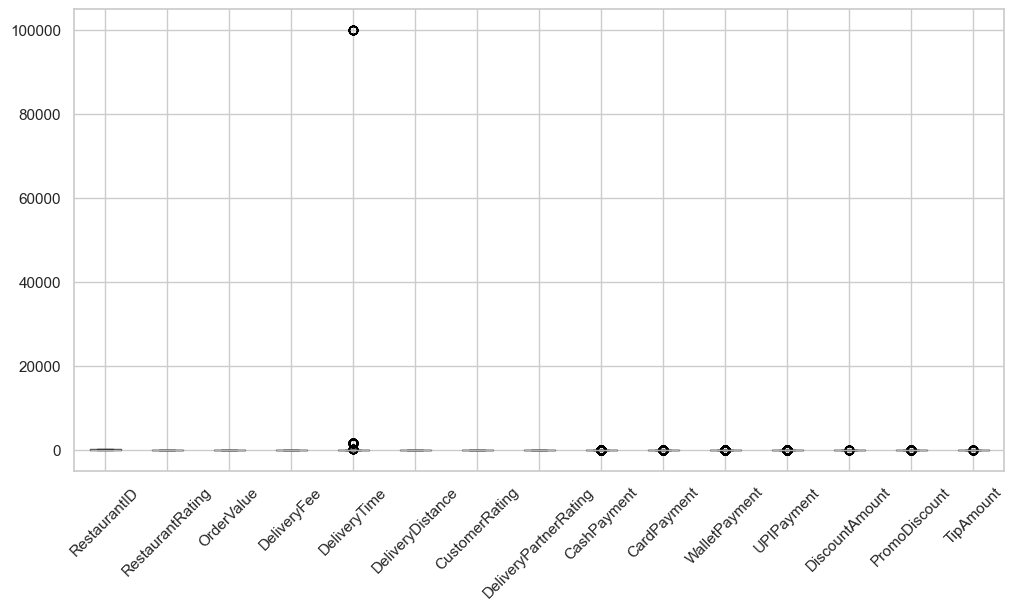

In [832]:
#all numeric columns in boxplot
df.drop(columns=['OrderID']).boxplot(figsize=(12,6))
plt.xticks(rotation=45)
plt.show()

In [833]:
#capping all values with the upper_limit and lower_limit
def caping (col):
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    iqr=q3 - q1
    lower_limit=q1 - (1.5*iqr)
    upper_limit=q3 + (1.5*iqr)

    df[col]=np.where(df[col]>=upper_limit,upper_limit,
                     np.where(df[col]<=lower_limit,lower_limit,df[col]))

#taking all features those have outliers
has_outliers=['DeliveryTime','DeliveryPartnerRating','CashPayment','CardPayment',
              'UPIPayment','DiscountAmount','PromoDiscount','TipAmount']
for i in has_outliers:
    caping(i)

#### 6. Reshape Data Using Melt
Use the melt() function to reshape the payment data from wide to long format.
Scenario: The dataset has separate columns for different payment methods:CashPayment
- CardPayment
- WalletPayment
- UPIPayment

For each order, only one payment method column contains the OrderValue, while others are 0.

Task: Combine these columns into:
- A single PaymentMethod column
- A single PaymentAmount column
- Filter out rows where PaymentAmount = 0 (since each order uses only one payment method)

In [834]:
Payment_df=pd.melt(df,id_vars=['OrderID'],value_vars=['CashPayment','CardPayment','WalletPayment','UPIPayment'],
        var_name="PaymentMethod",value_name='PaymentAmount')  #melting data then created a new df called Payment_df
Payment_df=Payment_df[Payment_df['PaymentAmount'] > 0]   #find out paymentAmount>0
df=df.merge(Payment_df,on='OrderID', how='left')  #merging PaymentAmount column into main df
df=df.drop(columns=['CashPayment','CardPayment','WalletPayment','UPIPayment'])  #droping unnecessary columns

#### 7. Feature Engineering: Net Revenue
Add a new column called NetRevenue calculated as:

NetRevenue = OrderValue - (DiscountAmount + PromoDiscount) - RestaurantCommission

Where:
- DiscountAmount : Customer discount applied
- PromoDiscount : Promotional discount
- RestaurantCommission : Commission paid to the platform (typically 15-25% of OrderValue)

Task: Create this new feature and analyze which city generates the highest net revenue.

In [835]:
df["NetRevenue"]=df['OrderValue'] - (df['DiscountAmount'] + df['PromoDiscount']) - df['OrderValue']*.15  #calculating NetRevenue

In [836]:
highest_rev=df.loc[df['NetRevenue'].idxmax(), ['City','NetRevenue']]  #finding highest revenue city
print(f'{highest_rev.iloc[0]} generates highest revenue: {highest_rev.iloc[1]}')

South Zone generates highest revenue: 64.8215


### Section 4: Visualization Questions (6 Questions)
After cleaning the data, create the following visualizations:

#### 1. Bar Chart: Total Orders by Cuisine Type
Create a bar chart showing the total number of orders for each cuisine type ( Italian , Chinese , Indian , Fast Food , Mexican , etc.) across all cities.

Requirements:
- X-axis: Cuisine Type
- Y-axis: Total Orders
- Add title and axis labels
- Use different colors for each cuisine

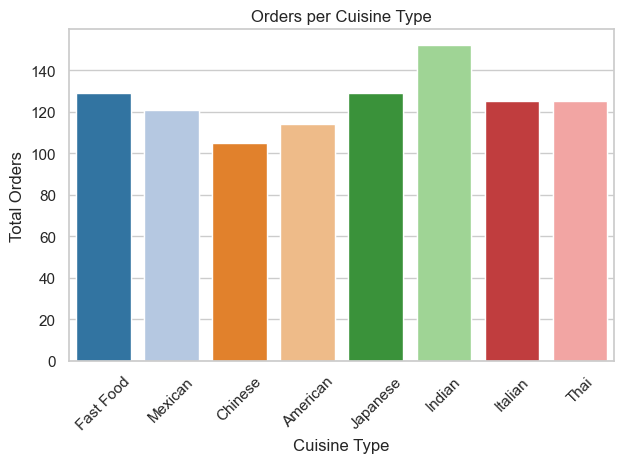

In [877]:
#visualization of barplot
counts=df['CuisineType'].value_counts()

sns.countplot(data=df,x='CuisineType',hue='CuisineType',palette='tab20',legend=False)
plt.xticks(rotation=45)
plt.xlabel("Cuisine Type")
plt.ylabel("Total Orders")
plt.title("Orders per Cuisine Type")
plt.tight_layout()
plt.show()

#### 2. Histogram: Delivery Time Distribution
Plot a histogram of the DeliveryTime column to analyze the distribution of delivery times after cleaning.

Requirements:
- Use appropriate bins (e.g., 20-30 bins)
- Add title: "Distribution of Delivery Times"
- Mark the mean and median with vertical lines
- Add a legend

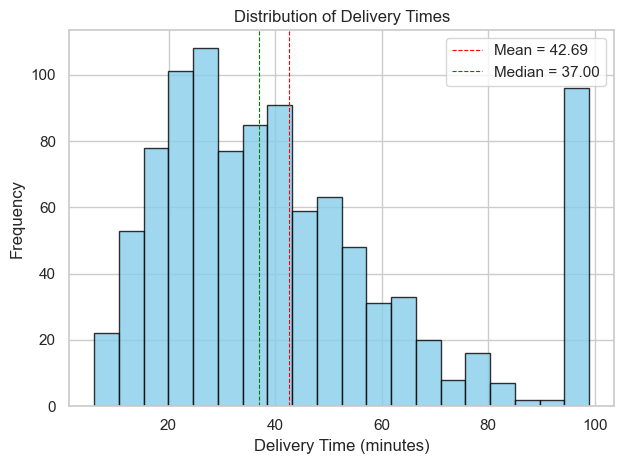

In [880]:
#visualization of histogram
plt.hist(df['DeliveryTime'],bins=20,color='skyblue',edgecolor='black',alpha=0.8)  #ploting histogram

avg_val=df['DeliveryTime'].mean()  #average value
median_val=df['DeliveryTime'].median()  #median value
plt.axvline(avg_val, color='red', linestyle='--', linewidth=.8,label=f"Mean = {avg_val:.2f}")   #avarage value axis label
plt.axvline(median_val, color='green', linestyle='--', linewidth=.8,label=f"Median = {median_val:.2f}")  #median value axis label

plt.title('Distribution of Delivery Times')
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

#### 3. Pie Chart: Customer Segment Proportion
Create a pie chart displaying the proportion of orders across customer segments:
- New Customer
- Regular Customer
- VIP Customer

Requirements:
- Show percentages on each slice
- Use contrasting colors
- Add a title

In [839]:
#visualization of pieplot
fig=px.pie(df,names='CustomerSegment',values='OrderValue',title='Orders across customer segments',
    color_discrete_sequence=px.colors.qualitative.Bold)  #ploting CustomerSegment with plotly

fig.show()

#### 4. Scatterplot: Order Value vs. Delivery Time
Generate a scatterplot to analyze the relationship between OrderValue and DeliveryTime .

Requirements:
- X-axis: Order Value
- Y-axis: Delivery Time
- Color points by CustomerSegment
- Add a trend line
- Include correlation coefficient in the title

In [ ]:
#visualization of scatter plot
corr=df['OrderValue'].corr(df['DeliveryTime']) # calculating correlation value

fig = px.scatter(df, x='OrderValue', y='DeliveryTime', title="Order Value VS Delivery Time "+f' Corelation coefficient: {corr:.2f}', 
                 trendline='ols', color='CustomerSegment',size='OrderValue',
                 color_discrete_sequence=px.colors.qualitative.Bold, width=1000, height=600)
fig.show()

#### 5. Boxplot: Delivery Time by City
Create a boxplot to visualize the spread and outliers in DeliveryTime for each city.

Requirements:
- X-axis: City
- Y-axis: Delivery Time (minutes)
- Identify which city has the most consistent delivery times
- Highlight outliers

In [841]:
#visualization of boxplot
fig_box=px.box(df,x='City',y='DeliveryTime',title='Delivery Time by City')

fig_box.update_traces(
    marker=dict(color='red', size=8, symbol='circle-open'),
    line=dict(color='blue'))

fig_box.show()

Most Consistent Delivery Times is West Zone. Because West zone has smallest iqr and shorter whiskers.

#### 6. Line Chart: Daily Order Trends
Create a line chart showing daily order trends throughout the month for each cuisine category.

Requirements:
- X-axis: Date
- Y-axis: Number of Orders
- Multiple lines (one for each major cuisine type)
- Add legend
- Identify peak ordering days

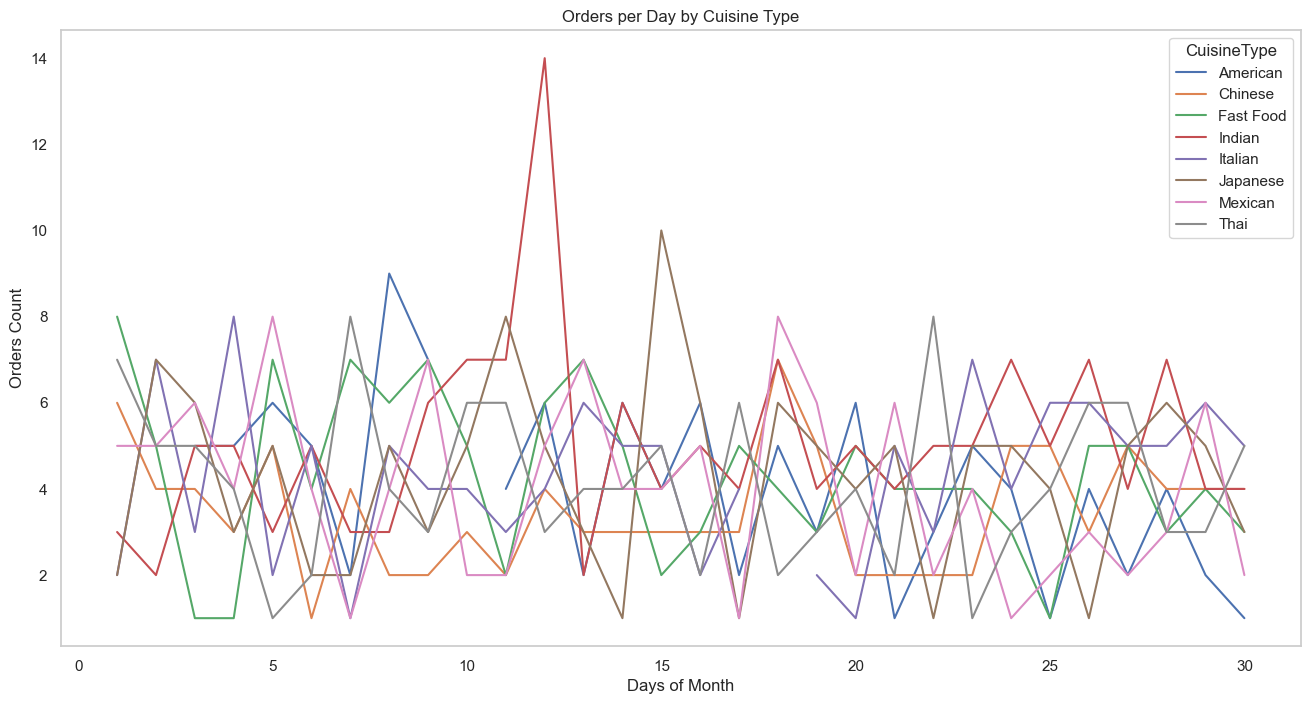

In [842]:
#line plot visualization
fig,ax=plt.subplots(figsize=(16,8))

counts=df.groupby([df['OrderDate'].dt.day, 'CuisineType']).size().unstack()
counts.plot(ax=ax)
ax.set_xlabel("Days of Month")
ax.set_ylabel("Orders Count")
ax.set_title("Orders per Day by Cuisine Type")
ax.grid(which='major')
plt.show()

From the visual analysis of daily cuisine orders, 
- Day 12 is the highest single day order value for Indian CUisine
- Day 15 to 16 Multiple cuisines (Fast Food, Japanese, Thai, Mexican) show rises,
- Day 18 to 20 Noticeable increases across several cuisines like Chinese, Mexican, Italian, Thai

### Section 5: Statistical Test Questions (10 Questions)

#### 1. Independent Samples T-Test: Premium vs. Regular Customers
Problem Statement:

FoodExpress wants to understand if customer segment affects ratings. Conduct an independent samples t-test to determine if there is a statistically significant difference in average customer ratings between VIP Customers and Regular Customers .

Requirements:
- H₀ (Null Hypothesis): There is no difference in mean ratings between VIP and Regular customers
- H₁ (Alternative Hypothesis): There is a significant difference in mean ratings
- Use α = 0.05 significance level
- Calculate t-statistic and p-value
- Interpret results in business context
- Create a visualization comparing rating distributions for both groups

In [843]:
rate_vip=df[df['CustomerSegment']=='VIP Customer']['CustomerRating']  #only Vip Customers rating
rate_regular=df[df['CustomerSegment']=='Regular Customer']['CustomerRating']   #only Regular Customers rating

from scipy.stats import ttest_ind #importing independent-samples t-test function
s_stats,p_value= ttest_ind(a=rate_vip,b=rate_regular)   #getting t-statistics and P values from the funciton
print(f"T-statistics{s_stats:.2f} \nP-value : {p_value:.3f}") 

T-statistics-1.05 
P-value : 0.292


#### Interpretation
while pvalue is greater than the alpha value we reject the null hypothesis (H0). which means, There is no significant difference found between VIP and Regular customers. VIP status does not strictly correlate with higher/lower ratings in this sample."

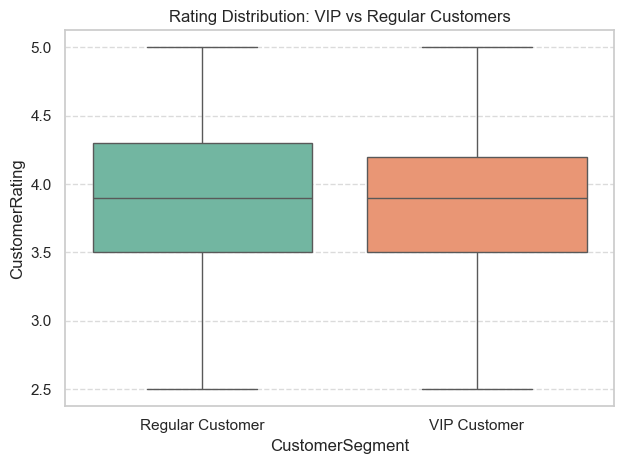

In [884]:
#visualizing Customer Segment category with their rating data to explain difference
vipNreg_customers=df[(df['CustomerSegment']=='VIP Customer') | (df['CustomerSegment']=='Regular Customer')]  #vip & regular customers df
sns.boxplot(x='CustomerSegment', y='CustomerRating', data=vipNreg_customers, palette="Set2",hue='CustomerSegment')
plt.title('Rating Distribution: VIP vs Regular Customers')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. One-Sample T-Test: Delivery Time Target
Problem Statement:
The operations team has set a target average delivery time of 30 minutes for the North Zone . Test whether the North Zone is meeting this target using a one-sample t-test.

Requirements:
- H₀: The mean delivery time in North Zone is 30 minutes (μ = 30)
- H₁: The mean delivery time in North Zone is NOT 30 minutes (μ ≠ 30)
- Use α = 0.05
- Calculate t-statistic and p-value
- Provide clear interpretation
- Recommend operational improvements if target is not met

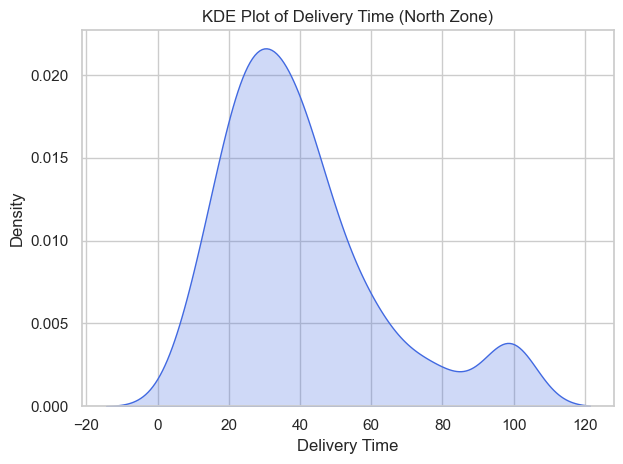

In [887]:
#checking normality for DeliveryTime
north_Dt=df[df['City']=="North Zone"]['DeliveryTime']  #north zone DeliveryTime

sns.kdeplot(north_Dt, fill=True,color='royalblue')
plt.title("KDE Plot of Delivery Time (North Zone)")
plt.xlabel("Delivery Time")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

In [846]:
#t-test for north zone delivery time
from scipy.stats import ttest_1samp
t_statistic, p_value = stats.ttest_1samp(a=north_Dt, popmean=30)
print(f"T-statistics: {t_statistic:.2f} \nP-value: {p_value:.5e}")

T-statistics: 7.36 
P-value: 2.45572e-12


While p-value is less than alpha value 0.000<0.05  We reject the null hypothesis. 
That means there are significantly difference from the mean value. So now,

In [847]:
print(f"Sample Mean: {np.mean(north_Dt):.2f} min")  #the sample mean value

Sample Mean: 40.38 min


Average delivery time 40.38 min is the huge. Recommended to
1.  By using route-optimization software, the delivery time will be faster
2.  Hire more delivery man and divide them into smaller areas to cover delivery in short time
3.  By giving some extra benefits to delivery man for delivering on time, the mean delivery time will be decrease

#### 3. Chi-Square Test of Independence: Payment Method and Customer Segment
Problem Statement:
The finance team wants to know if there's a relationship between payment methods ( Cash , Card , Wallet , UPI ) and customer segments ( New , Regular , VIP ). Since payment data is in wide format (CashPayment, CardPayment, WalletPayment, UPIPayment columns), you'll first need to create a PaymentMethod column by identifying which payment column has a value > 0 for each order. Then conduct a chi-square test of independence.

Requirements:
- H₀: Payment method and customer segment are independent
- H₁: Payment method and customer segment are associated
- First, create a PaymentMethod column from the wide format payment data
- Create a contingency table
- Calculate expected frequencies
- Compute chi-square statistic and p-value
- Use α = 0.05
- Interpret practical significance

In [848]:
from scipy.stats import chi2_contingency  #importing chi2_contingency method

contingency_table=pd.crosstab(df['PaymentMethod'],df['CustomerSegment'])  #making contigency table
chi2, p, dof, expected=chi2_contingency(contingency_table)  #taking values into different varibles

print(f"Chi-square statistic: {chi2:.3f}") 
print(f"P-value: {p:.3f}")
print(f"Degrees of freedom: {dof}\n")
print(f"Expected frequencies:\n {expected}")

Chi-square statistic: 5.202
P-value: 0.518
Degrees of freedom: 6

Expected frequencies:
 [[80.91  85.347 94.743]
 [78.74  83.058 92.202]
 [82.15  86.655 96.195]
 [68.2   71.94  79.86 ]]


#### Interpretation
Beacause of P-value is greater than α = 0.05 which is 0.518, we reject the null hypothesis. This indicating insufficient evidence to conclude a relationship relation between Payment Method and Customer Segment.

#### 4. Chi-Square Goodness of Fit: Cuisine Distribution
Problem Statement:

The marketing team expects that orders should be evenly distributed across five major cuisines( Italian , Chinese , Indian , Fast Food , Mexican ) - each accounting for 20% of total orders. Test if the actual distribution matches this expectation.

Requirements:
- H₀: Orders are evenly distributed (20% each)
- H₁: Orders are not evenly distributed
- Calculate observed and expected frequencies
- Compute chi-square statistic and p-value
- Use α = 0.05
- Provide recommendations for marketing focus

In [849]:
from scipy.stats import chisquare  #importing chisquare methods
CuisineType=['Italian', 'Chinese', 'Indian', 'Fast Food', 'Mexican'] 
obs_f= df[df['CuisineType'].isin(CuisineType)]['CuisineType'].value_counts()  #observed frequencies
totalLen= sum(obs_f.values)  #total length of observed frequency
exp_f= [totalLen * 0.2]*5  #expected frequencies

print(f'Observed frequency: {obs_f}\n')
print(f'Observed frequency: {exp_f}\n')

dof=len(obs_f)-1   #degree of freedom
chi2, p = chisquare(f_obs=obs_f, f_exp=exp_f)
print(f"Chi-square statistic: {chi2:.3f}")
print(f"P-value: {p:.3f}\n")

Observed frequency: CuisineType
Indian       152
Fast Food    129
Italian      125
Mexican      121
Chinese      105
Name: count, dtype: int64

Observed frequency: [np.float64(126.4), np.float64(126.4), np.float64(126.4), np.float64(126.4), np.float64(126.4)]

Chi-square statistic: 9.108
P-value: 0.058



#### Interpretation
While the p-value is greater than 0.05, we fail to reject the null hypothesis. This means that the observed distribution of cuisine types in the sample does not differ significantly from the expected distribution.

### Correlation Analysis

#### 5. Correlation Analysis: Order Value, Delivery Time, and Ratings
Problem Statement:
The analytics team wants to understand relationships between:
- Order Value and Customer Rating
- Delivery Time and Customer Rating
- Order Value and Delivery Time

Requirements:
- Calculate Pearson correlation coefficients for each pair
- Test statistical significance
- Create a correlation heatmap
- Generate scatterplots with trend lines
- Interpret findings and suggest operational improvements

In [850]:
from scipy.stats import pearsonr

#OrderValue vs CustomerRating
rel1,pvalue1=pearsonr(df['OrderValue'], df['CustomerRating'])
print(f"Order Value vs Rating: relation= {rel1:.3f}, p-value= {pvalue1:.3f}")

#DeliveryTime vs CustomerRating
rel2, pvalue2=pearsonr(df['DeliveryTime'], df['CustomerRating'])
print(f"Delivery Time vs Rating: relation= {rel2:.3f}, p-value= {pvalue2:.3f}")

#OrderValue vs DeliveryTime
rel3, pvalue3 =pearsonr(df['OrderValue'], df['DeliveryTime'])
print(f"Order Value vs Delivery Time: relation= {rel3:.3f}, p-value= {pvalue3:.3f}")


Order Value vs Rating: relation= 0.028, p-value= 0.382
Delivery Time vs Rating: relation= -0.459, p-value= 0.000
Order Value vs Delivery Time: relation= -0.012, p-value= 0.704


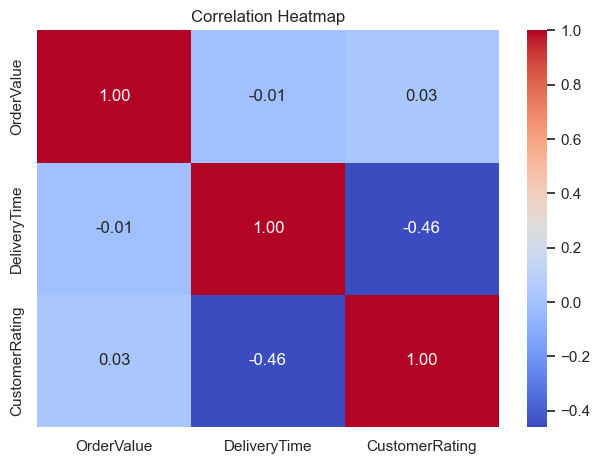

In [902]:
#Creating correlation heatmap
corr_mat=df[['OrderValue','DeliveryTime','CustomerRating']].corr()  #correlation matrix

sns.heatmap(corr_mat, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

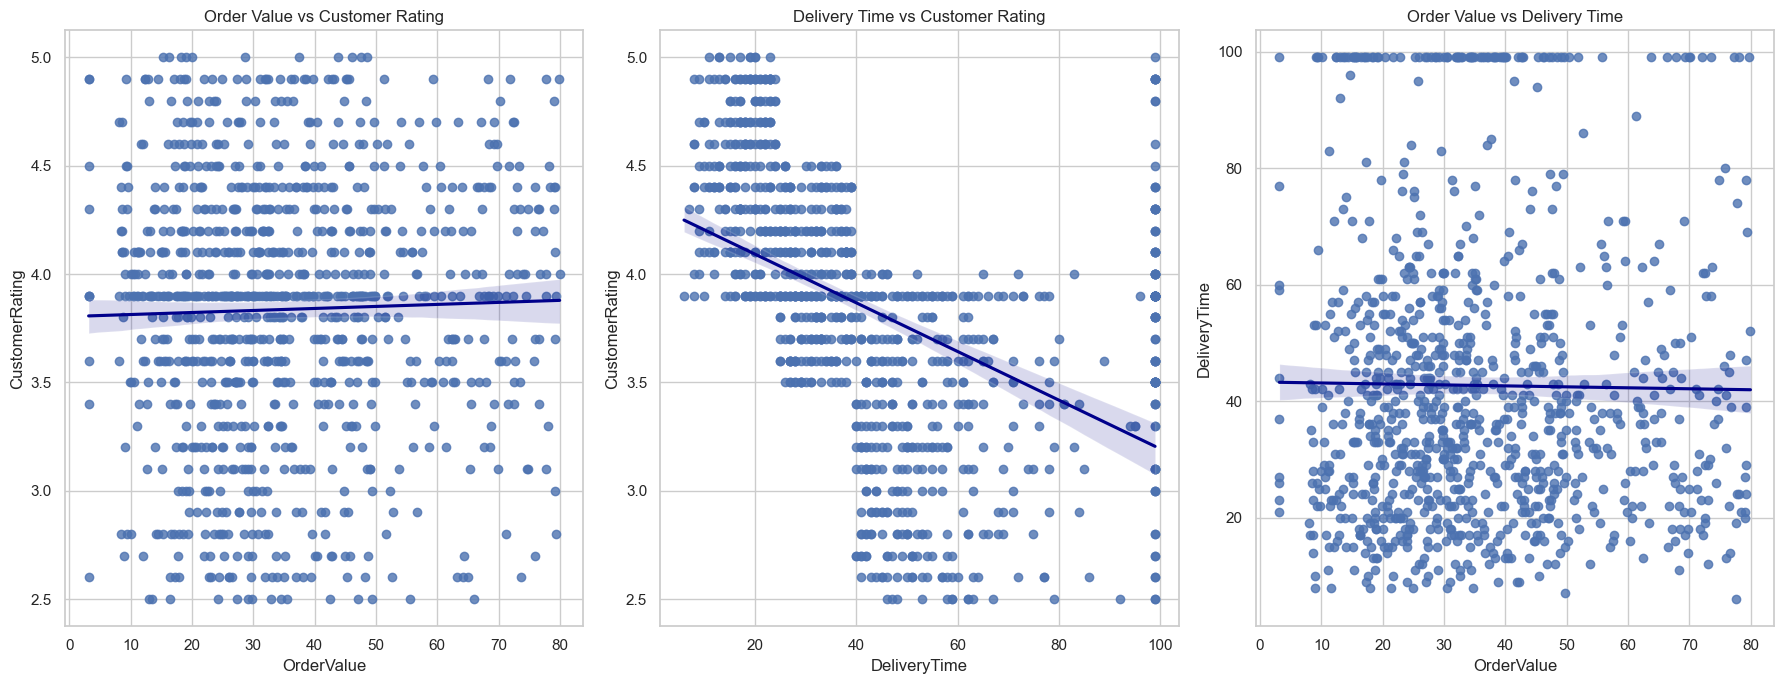

In [905]:
#Generating scatterplots with trend lines
fig,axes=plt.subplots(1,3,figsize=(18, 7))

#OrderValue vs CustomerRating
sns.regplot(x='OrderValue', y='CustomerRating',data=df,ax=axes[0],line_kws={'color':'darkblue'})
axes[0].set_title("Order Value vs Customer Rating")

#DeliveryTime vs CustomerRating
sns.regplot(x='DeliveryTime', y='CustomerRating', data=df,ax=axes[1],line_kws={'color':'darkblue'})
axes[1].set_title("Delivery Time vs Customer Rating")

#OrderValue vs DeliveryTime
sns.regplot(x='OrderValue', y='DeliveryTime', data=df,ax=axes[2],line_kws={'color':'darkblue'})
axes[2].set_title("Order Value vs Delivery Time")

plt.tight_layout()
plt.show()

### Interpretation
#### Order Value vs Customer Rating
- There are almost flat ralation between OrderValue and Rating which indicates higher order value doesn't affect on rating. Customers give almost same rating in different order value

#### Delivery time vs Customer Rating
- There are a strong negative Correlation between Delivery time and Cutomer rating. Indicating when delivery time increase, customer rating will be decrease. Higher delivery time = Lower customer rating

#### Order Value vs Delivery time
- Weak relation between them almost flat. This can proof that bigger orders do not take longer delivery time. Delivery times are not tied with small or bigger value orders.

Suggestion: 
- For decreasing delivery time, use clustering orders by zone.
- increas delivery staff during the peak hours.
- Identify high delay zone and hire delivert partners near that zone.
- Monitor delivery partners performance in real-time
- Since order value doesn't affect on ratings, offer some attractive packeges for loyal customers also reward top performers

#### 6. Multiple Correlation: Restaurant Rating Prediction
Problem Statement:
Identify which factors most strongly correlate with RestaurantRating :
- Order Value
- Delivery Time
- Discount Percentage
- Number of Previous Orders (customer history)

Requirements:
- Calculate correlation coefficients for each factor
- Determine the strongest predictor
- Create visualizations
- Suggest actions for restaurant partnership team

In [853]:
df.columns

Index(['OrderID', 'OrderDate', 'OrderTime', 'City', 'CustomerSegment',
       'CuisineType', 'RestaurantID', 'RestaurantRating', 'OrderValue',
       'DeliveryFee', 'DeliveryTime', 'DeliveryDistance', 'CustomerRating',
       'DeliveryPartnerRating', 'DiscountAmount', 'PromoDiscount', 'TipAmount',
       'TimePeriod', 'WeatherCondition', 'DayOfWeek', 'PaymentMethod',
       'PaymentAmount', 'NetRevenue'],
      dtype='object')

DiscountAmount vs RestaurantRating: r= 0.032, p= 0.31039
PromoDiscount vs RestaurantRating: r= -0.004, p= 0.90588
OrderValue vs RestaurantRating: r= 0.019, p= 0.54566
DeliveryTime vs RestaurantRating: r= 0.048, p= 0.12606
DiscountPercent vs RestaurantRating: r= 0.017, p= 0.59184

DeliveryTime has Strongest Predictor with Restaurant Rating: r= 0.048


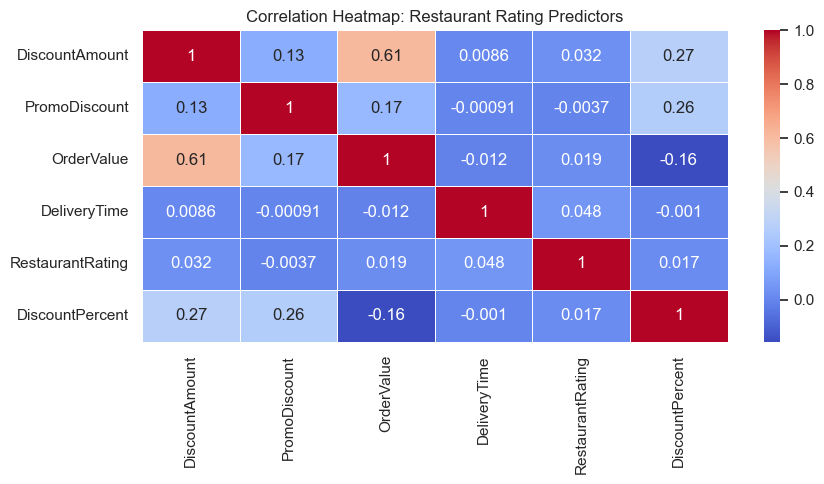

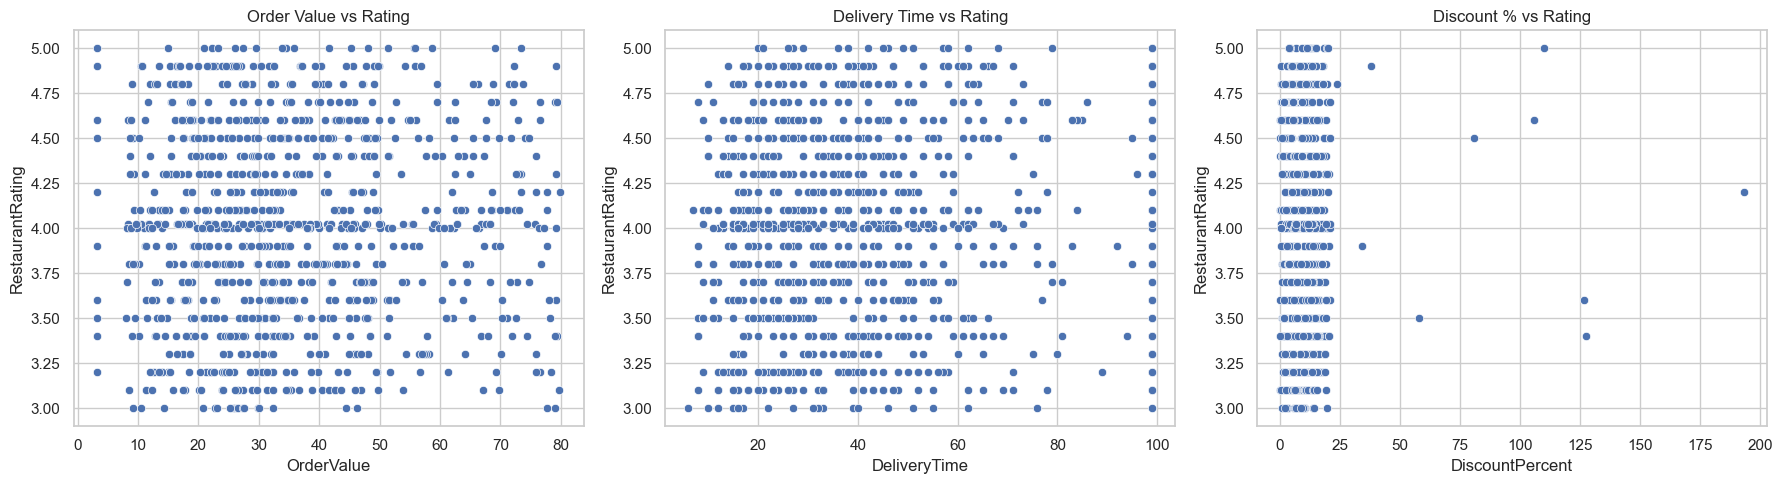

In [908]:
corrDf= df[['DiscountAmount','PromoDiscount','OrderValue', 'DeliveryTime','RestaurantRating']].copy()  #taking necessary columns
corrDf['DiscountPercent']= (corrDf['DiscountAmount'] + corrDf['PromoDiscount']) / corrDf['OrderValue'] * 100   #calculating discountPercent

m=0
for i in corrDf.drop('RestaurantRating',axis=1).columns:
    corrValue=pearsonr(corrDf[i], df['RestaurantRating'])
    print(f"{i} vs RestaurantRating: r= {corrValue[0]:.3f}, p= {corrValue[1]:.5f}")
    if corrValue[0]>m:
        m=corrValue[0]
        j=i
print(f"\n{j} has Strongest Predictor with Restaurant Rating: r= {m:.3f}")

corr_matrix =corrDf.corr()

sns.set(style="whitegrid")

# Heatmap
plt.figure(figsize=(9,5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap: Restaurant Rating Predictors")
plt.tight_layout()
plt.show()

# Scatterplots
plt.figure(figsize=(18,5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='OrderValue', y='RestaurantRating', data=corrDf)
plt.title("Order Value vs Rating")

plt.subplot(1, 3, 2)
sns.scatterplot(x='DeliveryTime', y='RestaurantRating', data=corrDf)
plt.title("Delivery Time vs Rating")

plt.subplot(1, 3, 3)
sns.scatterplot(x='DiscountPercent', y='RestaurantRating', data=corrDf)
plt.title("Discount % vs Rating")

plt.tight_layout()
plt.show()

- All correlations with RestaurantRating are extremely weak, all r values are between –0.05 and 0.05
- DeliveryTime is the strongest predictor, but still very weak, r = 0.048
- OrderValue, Discounts, PromoDiscount, no meaningful effect on ratings. That means restaurants are being rated mostly based on food quality and service but not pricing or delivery conditions.

#### Suggestions:
- Improve Meal Quality Instead of Playing With Discounts. It may gather some short-term customers but not for long-term
- Reduce Delivery Time for Low-Rated Restaurants. Improve kitchen prep time though it needs nore staffs in peak hour.
- Improve Packaging Quality for High-Spill Risk Items. Because this type of foods are highly affect on rating
- Provide Restaurants With a Customer Feedback. THis helps to find which things are mostly affect on RestaurantRating

### ANOVA Tests

#### 7. One-Way ANOVA: Delivery Time Across Cities
Problem Statement:
Test if there are significant differences in mean delivery times across the four cities ( North Zone , South Zone , East Zone , West Zone ).

Requirements:
- H₀: Mean delivery times are equal across all cities
- H₁: At least one city has a different mean delivery time
- Calculate F-statistic and p-value
- Use α = 0.05
- If significant, conduct post-hoc tests (Tukey HSD) to identify which cities differ
- Create boxplot comparing delivery times
- Provide operational recommendations

In [909]:
#importing necessary methods from stats
import statsmodels.formula.api as sm
from statsmodels.stats.anova import anova_lm

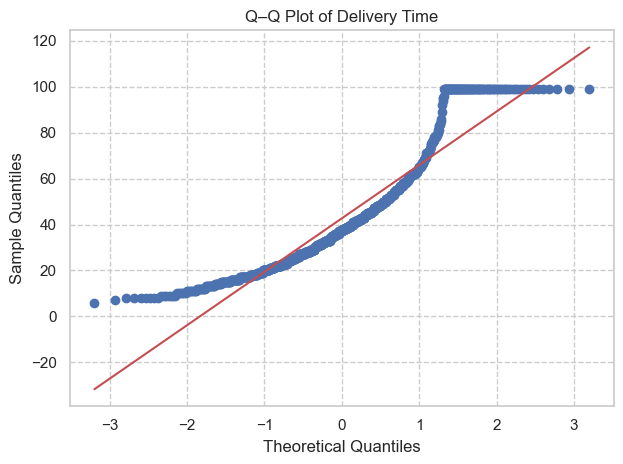

In [913]:
#Visualization of DeliveryTime with QQ-plot
stats.probplot(df['DeliveryTime'], dist="norm", plot=plt)

plt.title("Q–Q Plot of Delivery Time")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

In [857]:
df['City'].value_counts()  #counting orders by city

City
West Zone     259
North Zone    259
East Zone     243
South Zone    239
Name: count, dtype: int64

In [858]:
#ANOVA-test
model=sm.ols('DeliveryTime ~ C(City)',data=df).fit()    
anova_data= anova_lm(model)
anova_data

,df,sum_sq,mean_sq,F,PR(>F)
C(City),3.0,2816.39418,938.798060,1.557029,0.198245
Residual,996.0,600529.96982,602.941737,NaN,NaN


From p-value we see that, this anova-test is statistically not significant. We may not reject the null hypothesis. That indicates, There is not enough evidence to conclude that the mean delivery times differ across the four cities (North, South, East, and West Zones). There is no statistical indication that any specific city zone has faster or slower delivery times than the others.

In [859]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [860]:
#post-hoc test by tuckey
tukey= pairwise_tukeyhsd(endog=df['DeliveryTime'],groups=df['City'])
print(tukey)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1     group2   meandiff p-adj   lower   upper  reject
------------------------------------------------------------
 East Zone North Zone  -2.8976 0.5495  -8.541  2.7458  False
 East Zone South Zone   1.7536 0.8618 -4.0029  7.5102  False
 East Zone  West Zone  -0.9825   0.97 -6.6259  4.6608  False
North Zone South Zone   4.6512   0.15 -1.0165 10.3189  False
North Zone  West Zone   1.9151 0.8114 -3.6377  7.4678  False
South Zone  West Zone  -2.7362    0.6 -8.4039  2.9315  False
------------------------------------------------------------


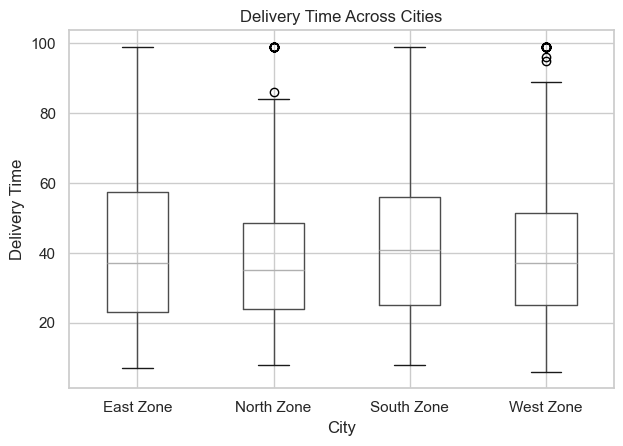

In [916]:
# Visualization Delivery time with different cities
df.boxplot(column="DeliveryTime", by="City")
plt.title("Delivery Time Across Cities")
plt.suptitle("") 
plt.xlabel("City")
plt.ylabel("Delivery Time")
plt.tight_layout()
plt.show()

#### Operational Recommendations
- West & North Zones need slightly more delivery fleet. Add 1–2 additional peak-hour drivers in these two zones.
- Many delivery times look like preparation delays which shows as outliers. So, introduce monitoring system and find restaurants with high prep-time variance.
- Give priority delivery to Vip customers

### Paired T-Tests

#### 9. Paired T-Test: Weekend vs. Weekday Performance
Problem Statement:

Compare delivery performance (average delivery time) on weekends vs. weekdays for the same delivery partners. Conduct a paired t-test to see if delivery partners perform differently on weekends.

Requirements:
- H₀: No difference in mean delivery times between weekdays and weekends
- H₁: Significant difference exists
- Prepare paired data (same delivery partner on both periods)
- Calculate mean difference and standard error
- Compute t-statistic and p-value
- Use α = 0.05
- Visualize changes for individual delivery partners
- Suggest scheduling optimizations

In [862]:
weekendDf=df[df['DayOfWeek'].isin(['Friday','Saturday'])]  #creating df for weekend
weekendPer=weekendDf.groupby(by='RestaurantID')['DeliveryTime'].mean()  #weekend deliverytime mean

weekdayDf=df[~df['DayOfWeek'].isin(['Friday','Saturday'])]  #creating df for weekday
weekdayPer=weekdayDf.groupby(by='RestaurantID')['DeliveryTime'].mean()  #weekday deliverytime mean

paired_df=pd.DataFrame({'weekday': weekdayPer,'weekend': weekendPer}).fillna(0) #making a df for allign  weekdays and weekends

In [863]:
from scipy.stats import ttest_rel
# extract paired arrays
weekday_values=paired_df['weekday']  #weekday values
weekend_values=paired_df['weekend']   #weekend values

#paired t-test
t_stat, p_val = ttest_rel(weekday_values, weekend_values)
print("Paired t-test results:")
print("t-statistic:", t_stat)
print("p-value:", p_val)

Paired t-test results:
t-statistic: 2.7264886480184365
p-value: 0.007169341424903452


In [864]:
#visualization of deliverypartners performence
fig = px.line(paired_df, x=paired_df.index, y=[paired_df['weekday'], paired_df['weekend']], markers=True,
    labels={'x':'RestaurantID (Delivery Partner)', 'value':'Average Delivery Time'},
    title='Delivery Partner Performance: Weekend vs Weekday')

fig.update_layout( legend=dict(title='DayType'),
    yaxis_title='Average Delivery Time',width=1100,height=500)
fig.show()

In [865]:
weekday_mean=paired_df['weekday'].mean()  #weekday mean value
weekend_mean=paired_df['weekend'].mean()  #weekend mean value
diff=paired_df['weekday'] - paired_df['weekend']  #paired differences
sd=diff.std(ddof=1) #standard deviation of differences
se=sd/(len(diff)**0.5) #standard error

print(f"Weekday Mean = {weekday_mean:.2f}")
print(f"Weekend Mean = {weekend_mean:.2f}")
print(f"Standard Error = {se:.2f}")

Weekday Mean = 43.11
Weekend Mean = 36.44
Standard Error = 2.45


While p-value is less than alpha=0.05,we reject the null hypothesis. There is statistically significant difference in average delivery time between weekday and weekend performance for the same delivery partners. Traffic may smoother on weekends, and order density may be lower in morning/afternoon compared to weekday rush hours

#### Suggestions
- Reassign More Delivery Partners to Weekday peak Hours between 12 PM – 3 PM and 6 PM – 9 PM.
- Because of havier delivery time reduce long-distance assignments on weekdays peak hours.
- reduce weekday delivery time, offer discounts or rewards for pre-orders placed before lunch/dinner rush.
- Using a predictive model to forecast weekday order volume, it will be help for preperation.
- While se is 2.45 which is moderate, there are some specific restaurants whos have long preparation time. Identify those restaurants to decrease high-variance.

#### 10. Paired T-Test: Before and After Promotional Campaign
Problem Statement: 
FoodExpress ran a promotional campaign in Week 2 of the month. Compare average order values before (Week 1) and after (Week 3) the campaign for the same restaurants to measure campaign effectiveness.

Requirements:
- H₀: No difference in average order values before and after campaign
- H₁: Campaign significantly affected order values
- Prepare paired data (same restaurants in both periods)
- Calculate mean difference and its standard error
- Compute t-statistic and p-value
- Use α = 0.05
- Create visualization comparing order values by restaurant
- Provide ROI analysis and recommendations

In [866]:
df.columns

Index(['OrderID', 'OrderDate', 'OrderTime', 'City', 'CustomerSegment',
       'CuisineType', 'RestaurantID', 'RestaurantRating', 'OrderValue',
       'DeliveryFee', 'DeliveryTime', 'DeliveryDistance', 'CustomerRating',
       'DeliveryPartnerRating', 'DiscountAmount', 'PromoDiscount', 'TipAmount',
       'TimePeriod', 'WeatherCondition', 'DayOfWeek', 'PaymentMethod',
       'PaymentAmount', 'NetRevenue'],
      dtype='object')

In [867]:
w1Df=df[df['OrderDate'].dt.day<=7]  #week1 df
w1Value= w1Df.groupby(by='RestaurantID')['OrderValue'].mean()  #grouping week1 average ordervalues by restaurantID

w3Df=df[(df['OrderDate'].dt.day>=15) | (df['OrderDate'].dt.day<=21)]  #week3 df
w3Value=w3Df.groupby(by='RestaurantID')['OrderValue'].mean()  #grouping week3 average ordervalues by restaurantID

w1_3Df=pd.DataFrame({'Week1': w1Value,'Week3': w3Value}).fillna(0) #making a df for allign columns  and filling null values wih 0

In [868]:
print(w1Value,"\n",w3Value,"\n",w1_3Df)

RestaurantID
102    39.932500
103    32.080000
107    33.810000
108    31.656667
110    27.340000
         ...    
246    63.430000
247    16.780000
248    27.160000
249    52.410000
250    32.666667
Name: OrderValue, Length: 123, dtype: float64 
 RestaurantID
101    33.598889
102    37.653750
103    30.061000
104    36.941667
105    36.490000
         ...    
246    37.912000
247    34.957000
248    33.254286
249    42.694000
250    29.961250
Name: OrderValue, Length: 150, dtype: float64 
                   Week1      Week3
RestaurantID                      
101            0.000000  33.598889
102           39.932500  37.653750
103           32.080000  30.061000
104            0.000000  36.941667
105            0.000000  36.490000
...                 ...        ...
246           63.430000  37.912000
247           16.780000  34.957000
248           27.160000  33.254286
249           52.410000  42.694000
250           32.666667  29.961250

[150 rows x 2 columns]


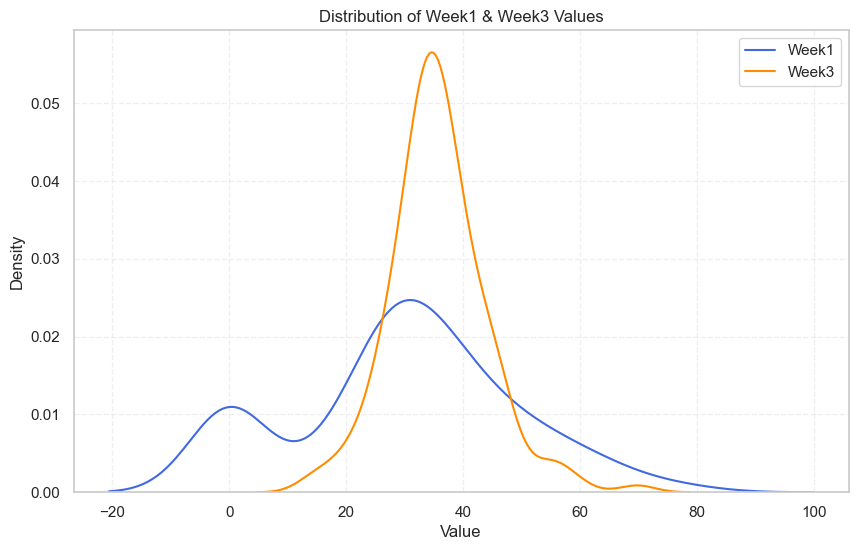

In [869]:
#checking normality for week1 and week3
plt.figure(figsize=(10,6))
sns.kdeplot(w1_3Df['Week1'], label="Week1", color="royalblue")
sns.kdeplot(w1_3Df['Week3'], label="Week3",color="darkorange")

plt.title("Distribution of Week1 & Week3 Values")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.3)
sns.set_style("whitegrid")
plt.show()

In [870]:
t_stat, p_val = ttest_rel(w1_3Df['Week1'],w1_3Df['Week3'])

print("Paired t-test Results:")
print(f"t-statistic: {t_stat:.3f}")
print(f"p-value: {p_val:.5f}")

Paired t-test Results:
t-statistic: -3.929
p-value: 0.00013


In [871]:
w1Mean= w1_3Df['Week1'].mean()  #week1 mean value
w3Mean= w1_3Df['Week3'].mean() #week3 mean value
dif= w1_3Df['Week1'] - w1_3Df['Week3']  #difference between week1 and week3 mean value
se=stats.sem(dif)  #calculating standard errors by sem method
perIncrease=((w3Mean-w1Mean)/w1Mean)*100  #calculating increse percentage

print(f"Week 1 Order value Mean: {w1Mean:.2f}")
print(f"Week 3 Order value Mean :{w3Mean:.2f}")
print(f"Standard Error(SE):{se:.4f}")
print(f"Percentage Increased :{perIncrease:.2f}%")

Week 1 Order value Mean: 30.05
Week 3 Order value Mean :35.74
Standard Error(SE):1.4488
Percentage Increased :18.94%


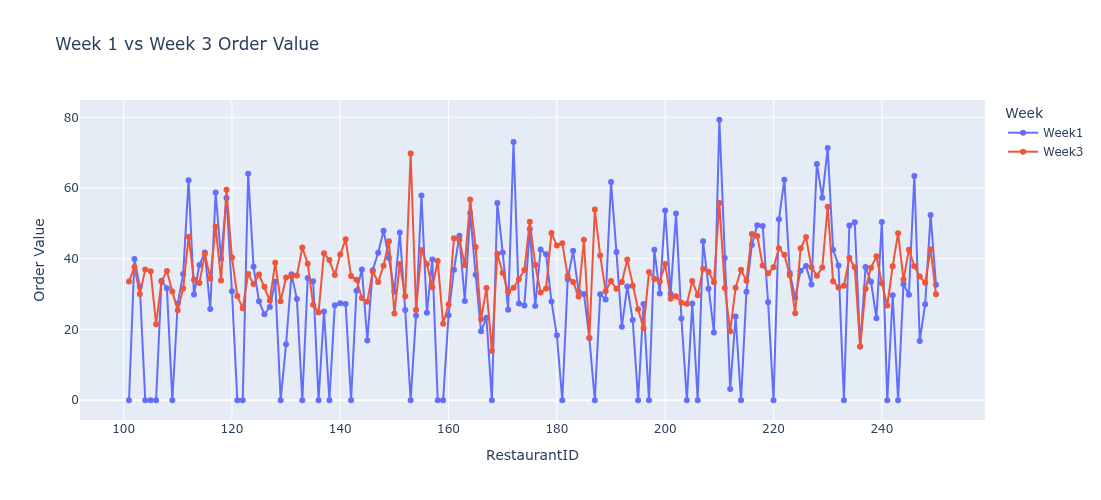

In [872]:
#Week1 and week3 order value performance
fig=px.line(w1_3Df, x=w1_3Df.index,y=['Week1', 'Week3'], labels={'x': 'Restaurant ID', 'value': 'Order Value', 'variable': 'Week'}, 
              title='Week 1 vs Week 3 Order Value', markers=True)
fig.update_layout(width=1200,height=500,showlegend=True)
fig.show()

THe p-value is less than 0.05, thats why we reject the null hypothesis. Means there are significant difference between before and after campaign order value mean. While Week3 average order value is greater than week1, the campaign affect positive on increasing order value.
#### Suggestions
- Continue the Successful promotion model similar discount offers, Combo/promotional bundles
- There are some restaurants whose have low ratings. Target those restaurants to cover up their low-ratings
- By using similar kind of campaign targeting low value customers, could help turn some of them into loyal customers
- Repeat the campaign every month with different items and structuers